In [2]:
import MDAnalysis as mda
import numpy as np
import re
import matplotlib.pyplot as plt
import pandas as pd
from MDAnalysis.lib.nsgrid import FastNS
from MDAnalysis.lib import mdamath 
from collections import defaultdict
from scipy.spatial import cKDTree
import math
import os
import matplotlib.pyplot as plt

lammps_data = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/N_0/lammps.data'
trajectory_file = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/N_0/traj.lammpstrj'
u = mda.Universe(lammps_data, trajectory_file, format='LAMMPSDUMP')


/home/user/anaconda3/lib/python3.12/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [81]:

total_chains = 650              # Set to actual polymer chain count in your system
polymer_type = 1                # Atom type for polymer
receptor_type = 2               # Atom type for receptor

num_bins = 50
max_distance = 50               # Maximum distance sphere radius (Angstrom)
bins = np.linspace(0, max_distance, num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

z_slab = 115.0                  # z where slab starts t(set for your system)
buffer = 0.0   
# Slab region definition
x_min, x_max = -30, 30
y_min, y_max = -30, 30
z_min, z_max = 32.2, 34.# Optionally set >0 to avoid near-boundary artifacts


In [82]:
def any_common_elements(list1, list2):
    set1 = set(list1)
    for element in set1:
        if element in list2:
            return True
    return False

def partner_array(resid_interest, cutoff, universe):
    array_partner = [resid_interest]
    atom_list = universe.select_atoms(f"around {cutoff:.2f} (resid {resid_interest})")
    for atom in atom_list:
        array_partner.append(atom.resid)
    return list(set(array_partner))

def max_clu(u, total_chains):
    partners_list = [partner_array(ele, 3.0, u) for ele in range(1, total_chains + 1)]
    max_length, max_list = 0, []
    for lst in partners_list:
        if len(lst) > max_length:
            max_length = len(lst)
            max_list = lst
    chain_in_cluster = max_list
    for chains in range(total_chains):
        if any_common_elements(chain_in_cluster, partners_list[chains]):
            chain_in_cluster += partners_list[chains]
            chain_in_cluster = list(set(chain_in_cluster))
    return chain_in_cluster

def is_chain_inside_box(chain, box, buffer=0.):
    for atom in chain.atoms:
        x, y, z = atom.position
        if not (buffer < x < box[0] - buffer and buffer < y < box[1] - buffer and buffer < z < box[2] - buffer):
            return False
    return True


Frame 0: largest polymer cluster = 16250 atoms, fraction = 1.000
Frame 1: largest polymer cluster = 16200 atoms, fraction = 0.997
Frame 2: largest polymer cluster = 15900 atoms, fraction = 0.978
Frame 3: largest polymer cluster = 15750 atoms, fraction = 0.969
Frame 4: largest polymer cluster = 15825 atoms, fraction = 0.974
Frame 5: largest polymer cluster = 15775 atoms, fraction = 0.971
Frame 6: largest polymer cluster = 15800 atoms, fraction = 0.972
Frame 7: largest polymer cluster = 15975 atoms, fraction = 0.983
Frame 8: largest polymer cluster = 15775 atoms, fraction = 0.971
Frame 9: largest polymer cluster = 15575 atoms, fraction = 0.958
Frame 10: largest polymer cluster = 15650 atoms, fraction = 0.963
Frame 11: largest polymer cluster = 15825 atoms, fraction = 0.974
Frame 12: largest polymer cluster = 15800 atoms, fraction = 0.972
Frame 13: largest polymer cluster = 15800 atoms, fraction = 0.972
Frame 14: largest polymer cluster = 15825 atoms, fraction = 0.974
Frame 15: largest po

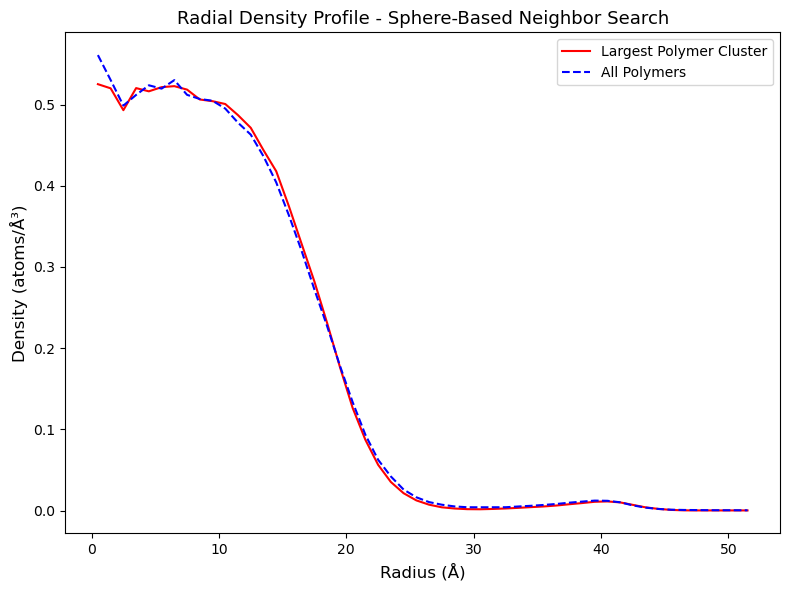

In [84]:
output_csv = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/N_0/polymer_cluster_analysis_sphere.csv'
output_table_csv = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/N_0/polymer_radial_density_table_sphere.csv'
output_plot = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/N_0/radialdensity_polymer_sphere.png'

polymer_type = 1
cutoff = 2.5
bin_width = 1.0
max_radius = 30 * math.sqrt(3)

u = mda.Universe(lammps_data, trajectory_file, format='LAMMPSDUMP')
polymers = u.select_atoms(f"type {polymer_type}")
total_polymers = len(polymers)

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0]*n
    def find(self, x):
        while self.parent[x]!=x:
            self.parent[x]=self.parent[self.parent[x]]
            x=self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra==rb: return
        if self.rank[ra]<self.rank[rb]:
            self.parent[ra]=rb
        else:
            self.parent[rb]=ra
            if self.rank[ra]==self.rank[rb]:
                self.rank[ra]+=1

def get_cell_index(pos, cell_size, box):
    return tuple((pos // cell_size).astype(int))

bins = np.arange(0, max_radius+bin_width, bin_width)
V_r = [(4/3)*np.pi*b**3 for b in bins]
shell_volumes = np.array([V_r[i+1]-V_r[i] for i in range(len(V_r)-1)])
bin_centers = 0.5*(bins[:-1]+bins[1:])

radial_density_cluster = np.zeros(len(shell_volumes))
radial_density_all = np.zeros(len(shell_volumes))
results = []

for ts in u.trajectory[0:399]:
    polymers.wrap(compound='fragments')
    positions = polymers.positions
    box = ts.dimensions[:3]
    cell_size = cutoff
    cell_dict = defaultdict(list)
    for i, pos in enumerate(positions):
        cell = get_cell_index(pos, cell_size, box)
        cell_dict[cell].append(i)
    neighbor_offsets = [(dx,dy,dz) for dx in [-1,0,1] for dy in [-1,0,1] for dz in [-1,0,1]]
    pairs = []
    for cell, atom_ids in cell_dict.items():
        for dx,dy,dz in neighbor_offsets:
            neighbor_cell = ((cell[0]+dx)%int(box[0]/cell_size),
                             (cell[1]+dy)%int(box[1]/cell_size),
                             (cell[2]+dz)%int(box[2]/cell_size))
            for i in atom_ids:
                for j in cell_dict.get(neighbor_cell, []):
                    if j<=i: continue
                    diff = positions[i] - positions[j]
                    diff -= box * np.round(diff / box)
                    if np.dot(diff, diff) <= cutoff**2:
                        pairs.append((i,j))
    uf = UnionFind(total_polymers)
    
    for i, j in pairs:
        uf.union(i,j)
    groups = defaultdict(list)
    
    for i in range(total_polymers):
        groups[uf.find(i)].append(i)
    largest_cluster = max(groups.values(), key=len)
    fraction = len(largest_cluster)/total_polymers
    print(f"Frame {ts.frame}: largest polymer cluster = {len(largest_cluster)} atoms, fraction = {fraction:.3f}")
    results.append([ts.frame, len(largest_cluster), fraction])
    
    cluster_positions = positions[largest_cluster]
    ref_com_cluster = cluster_positions.mean(axis=0)
    distances_cluster = np.linalg.norm(cluster_positions - ref_com_cluster, axis=1)
    hist_cluster, _ = np.histogram(distances_cluster, bins=bins)
    radial_density_cluster += hist_cluster
    
    ref_com_all = polymers.center_of_mass()
    distances_all = np.linalg.norm(positions - ref_com_all, axis=1)
    hist_all, _ = np.histogram(distances_all, bins=bins)
    radial_density_all += hist_all

df = pd.DataFrame(results, columns=["Frame","LargestClusterSize","Fraction"])
df.to_csv(output_csv, index=False)
n_frames = len(range(0,399))
radial_density_cluster /= (n_frames*shell_volumes)
radial_density_all /= (n_frames*shell_volumes)
density_df = pd.DataFrame({
    "Radius(Å)": bin_centers,
    "ClusterDensity(atoms/Å³)": radial_density_cluster,
    "AllPolymerDensity(atoms/Å³)": radial_density_all
})
density_df.to_csv(output_table_csv, index=False)

plt.figure(figsize=(8,6))
plt.plot(bin_centers, radial_density_cluster, label="Largest Polymer Cluster", color='r')
plt.plot(bin_centers, radial_density_all, label="All Polymers", color='b', linestyle='--')
plt.xlabel("Radius (Å)", fontsize=12)
plt.ylabel("Density (atoms/Å³)", fontsize=12)
plt.title("Radial Density Profile - Sphere-Based Neighbor Search", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

/home/user/anaconda3/lib/python3.12/site-packages/MDAnalysis/coordinates/LAMMPS.py:751: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


Frame 0: largest receptor cluster = 72 atoms, fraction = 0.288
Frame 1: largest receptor cluster = 73 atoms, fraction = 0.292
Frame 2: largest receptor cluster = 159 atoms, fraction = 0.636
Frame 3: largest receptor cluster = 159 atoms, fraction = 0.636
Frame 4: largest receptor cluster = 162 atoms, fraction = 0.648
Frame 5: largest receptor cluster = 173 atoms, fraction = 0.692
Frame 6: largest receptor cluster = 167 atoms, fraction = 0.668
Frame 7: largest receptor cluster = 175 atoms, fraction = 0.700
Frame 8: largest receptor cluster = 188 atoms, fraction = 0.752
Frame 9: largest receptor cluster = 201 atoms, fraction = 0.804
Frame 10: largest receptor cluster = 200 atoms, fraction = 0.800
Frame 11: largest receptor cluster = 206 atoms, fraction = 0.824
Frame 12: largest receptor cluster = 211 atoms, fraction = 0.844
Frame 13: largest receptor cluster = 216 atoms, fraction = 0.864
Frame 14: largest receptor cluster = 221 atoms, fraction = 0.884
Frame 15: largest receptor cluster = 

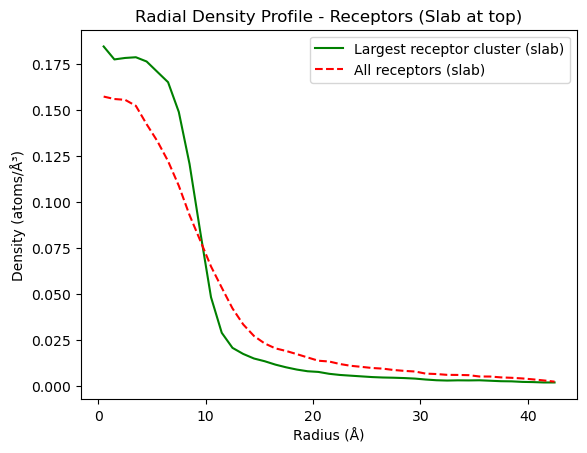

In [64]:
output_frame_csv = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_250/receptor_radial_density.csv'
output_density_csv = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_250/receptor_radial_density_table.csv'
output_plot = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_250/receptor_radial_density.png'
receptor_type = 2
cutoff = 2.5
bin_width = 1.0
max_radius = 30.0 * math.sqrt(2)
slab_thickness = 2.6

bins = np.arange(0, max_radius + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
shell_volumes = np.pi * slab_thickness * (bins[1:]**2 - bins[:-1]**2)

# Union-Find helper class
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0]*n

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb: return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        else:
            self.parent[rb] = ra
            if self.rank[ra] == self.rank[rb]:
                self.rank[ra] += 1

# Accumulators
radial_density_cluster = np.zeros(len(shell_volumes))
radial_density_all = np.zeros(len(shell_volumes))
valid_frames = 0
frame_results = []  # store frame-wise fraction info

# Loop over trajectory 
for ts in u.trajectory:
    Lz = ts.dimensions[2]
    receptors = u.select_atoms(f"type {receptor_type} and prop z>{Lz - slab_thickness}")
    total_receptors = len(receptors)
    if total_receptors == 0:
        continue

    # Cluster receptors
    ns = FastNS(cutoff, receptors.positions, ts.dimensions)
    pairs = ns.self_search().get_pairs()

    uf = UnionFind(total_receptors)
    for i, j in pairs:
        uf.union(i, j)

    groups = defaultdict(list)
    for i in range(total_receptors):
        groups[uf.find(i)].append(i)

    largest_cluster = max(groups.values(), key=len)
    fraction = len(largest_cluster) / total_receptors

    print(f"Frame {ts.frame}: largest receptor cluster = {len(largest_cluster)} atoms, fraction = {fraction:.3f}")
    frame_results.append([ts.frame, total_receptors, len(largest_cluster), fraction])

    # Radial density for largest cluster
    cluster_positions = receptors.positions[largest_cluster]
    ref_com_cluster = cluster_positions.mean(axis=0)
    distances_cluster = np.linalg.norm(cluster_positions - ref_com_cluster, axis=1)
    hist_cluster, _ = np.histogram(distances_cluster, bins=bins)
    radial_density_cluster += hist_cluster

    # Radial density for all receptors
    ref_com_all = receptors.center_of_mass()
    distances_all = np.linalg.norm(receptors.positions - ref_com_all, axis=1)
    hist_all, _ = np.histogram(distances_all, bins=bins)
    radial_density_all += hist_all

    valid_frames += 1

# Save frame-wise fraction CSV 
df_frame = pd.DataFrame(frame_results, columns=["Frame", "TotalReceptors", "LargestClusterSize", "Fraction"])
df_frame.to_csv(output_frame_csv, index=False)
print(f"\n Frame-wise receptor fraction saved to {output_frame_csv}")

# Normalize radial densities 
radial_density_cluster /= (valid_frames * shell_volumes)
radial_density_all /= (valid_frames * shell_volumes)

# Save radius-density table 
density_table = pd.DataFrame({
    "Radius (Å)": bin_centers,
    "Cluster Density (atoms/Å³)": radial_density_cluster,
    "All Receptors Density (atoms/Å³)": radial_density_all
})
density_table.to_csv(output_density_csv, index=False)
print(f"\n Radial density table saved to {output_density_csv}")

plt.plot(bin_centers, radial_density_cluster, label="Largest receptor cluster (slab)", color='g')
plt.plot(bin_centers, radial_density_all, label="All receptors (slab)", color='red', linestyle='--')
plt.xlabel("Radius (Å)")
plt.ylabel("Density (atoms/Å³)")
plt.legend()
plt.title("Radial Density Profile - Receptors (Slab at top)")
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

In [88]:
print(df.columns.tolist())

['Radius (Å)', 'Cluster Density (atoms/Å³)', 'All Receptors Density (atoms/Å³)']


<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1269873/2083973528.py:44: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('$r$ ($\sigma$)', fontsize=12)


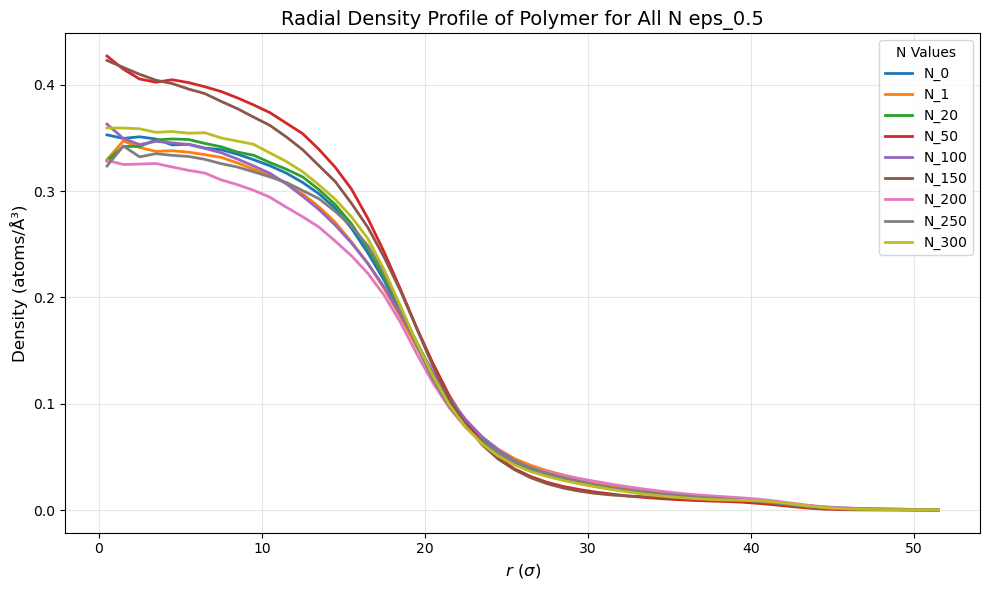


 Combined plot saved at: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/all_N_radial_density_plot.png


In [8]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'

# Automatically detect all folders starting with "N_"
n_folders = [f for f in os.listdir(root_folder) 
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort numerically

# Output plot path
output_plot = os.path.join(root_folder, 'all_N_radial_density_plot.png')

# Initialize plot
plt.figure(figsize=(10,6))

# Loop through folders
for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'polymer_radial_density_table_sphere.csv')
    
    # Check if CSV exists
    if not os.path.isfile(csv_file):
        print(f" CSV not found in {folder_path}, skipping...")
        continue
    
    # Load CSV
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f" Error reading {csv_file}: {e}")
        continue
    
    # Check required columns
    if 'Radius(Å)' not in df.columns or 'ClusterDensity(atoms/Å³)' not in df.columns:
        print(f" Required columns missing in {csv_file}, skipping...")
        continue
    
    # Extract data
    radius = df['Radius(Å)']
    cluster_density = df['ClusterDensity(atoms/Å³)']
    
    # Plot
    plt.plot(radius, cluster_density, label=n, linewidth=2)

# Plot formatting
plt.xlabel('$r$ ($\sigma$)', fontsize=12)
plt.ylabel('Density (atoms/Å³)', fontsize=12)
plt.title('Radial Density Profile of Polymer for All N eps_0.5', fontsize=14)
plt.legend(title='N Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Combined plot saved at: {output_plot}")


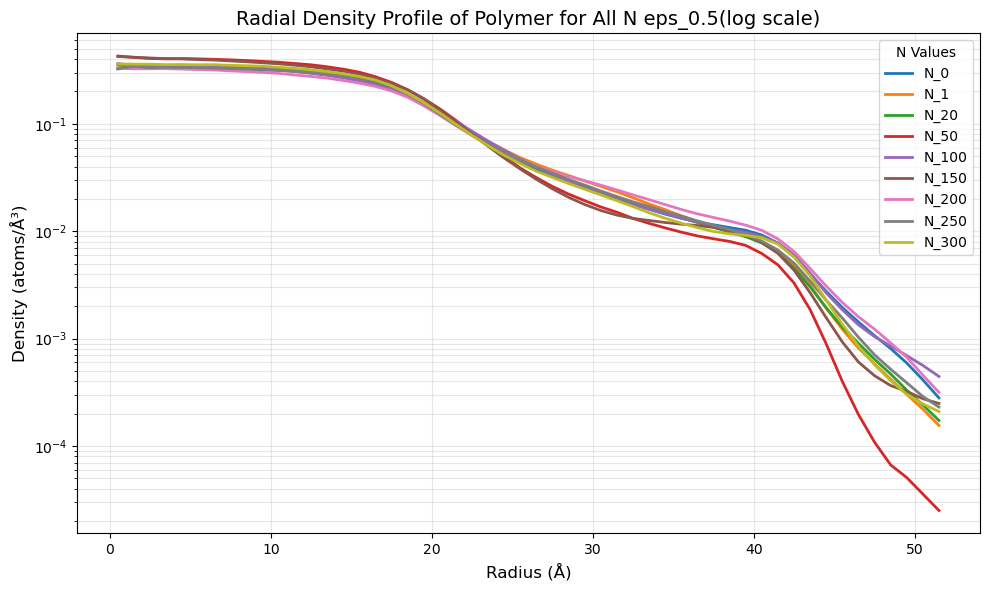


 Combined plot saved at: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/all_N_radial_density_plot_log.png


In [114]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'

# Automatically detect all folders starting with "N_"
n_folders = [f for f in os.listdir(root_folder) 
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort numerically

# Output plot path
output_plot = os.path.join(root_folder, 'all_N_radial_density_plot_log.png')

# Initialize plot
plt.figure(figsize=(10,6))

# Loop through folders
for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'polymer_radial_density_table_sphere.csv')
    
    # Check if CSV exists
    if not os.path.isfile(csv_file):
        print(f" CSV not found in {folder_path}, skipping...")
        continue
    
    # Load CSV
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f" Error reading {csv_file}: {e}")
        continue
    
    # Check required columns
    if 'Radius(Å)' not in df.columns or 'ClusterDensity(atoms/Å³)' not in df.columns:
        print(f" Required columns missing in {csv_file}, skipping...")
        continue
    
    # Extract data
    radius = df['Radius(Å)']
    cluster_density = df['ClusterDensity(atoms/Å³)']1.9e-05

    plt.plot(radius, cluster_density, label=n, linewidth=2)

plt.xlabel('$r$ ($\sigma$)', fontsize=12)
plt.ylabel('Density (atoms/Å³)', fontsize=12)
plt.yscale('log')  # Set y-axis to log scale
plt.title('Radial Density Profile of Polymer for All N eps_0.5(log scale)', fontsize=14)
plt.legend(title='N Values')
plt.grid(True, alpha=0.3, which='both')  # grid for both major and minor ticks
plt.tight_layout()

plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Combined plot saved at: {output_plot}")


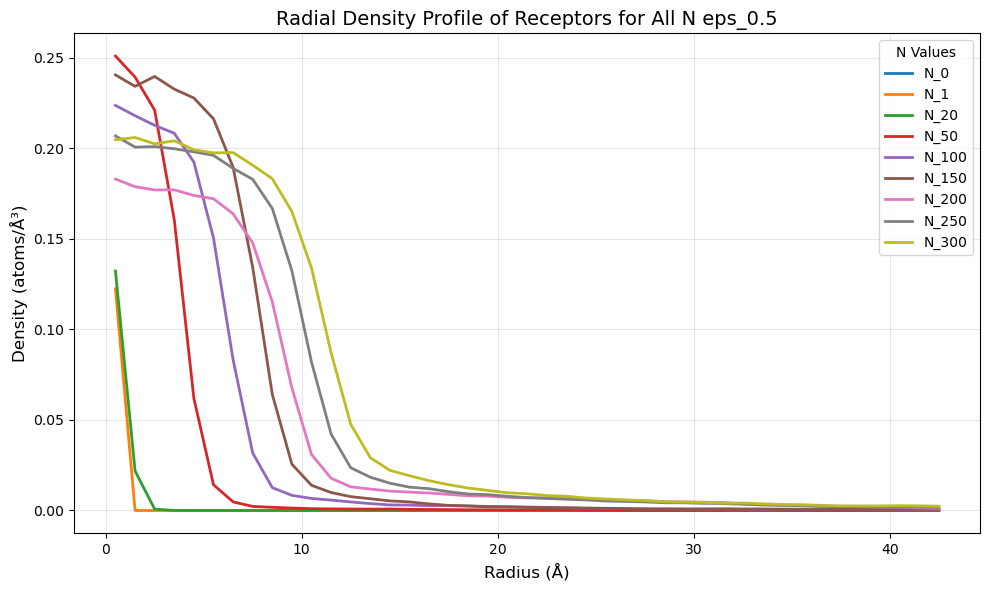


 Combined receptor plot saved at: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/all_N_receptor_radial_density_plot.png


In [115]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'

# Detect all folders starting with "N_"
n_folders = [f for f in os.listdir(root_folder) 
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
# Sort numerically by the number after N_
n_folders.sort(key=lambda x: int(x.split('_')[1]))

# Output plot path
output_plot = os.path.join(root_folder, 'all_N_receptor_radial_density_plot.png')

# Initialize plot
plt.figure(figsize=(10,6))

# Loop through folders
for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'receptor_radial_density_table.csv')
    
    if not os.path.isfile(csv_file):
        print(f" CSV not found in {folder_path}, skipping...")
        continue
    
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f" Error reading {csv_file}: {e}")
        continue
    
    # Check required columns
    required_cols = ['Radius (Å)', 'Cluster Density (atoms/Å³)']
    if not all(col in df.columns for col in required_cols):
        print(f" Required columns missing in {csv_file}, skipping...")
        continue
    
    # Extract data
    radius = df['Radius (Å)']
    cluster_density = df['Cluster Density (atoms/Å³)']
    
    # Plot cluster density
    plt.plot(radius, cluster_density, label=n, linewidth=2)

# Plot formatting
plt.xlabel('$r$ ($\sigma$)', fontsize=12)
plt.ylabel('Density (atoms/Å³)', fontsize=12)
plt.title('Radial Density Profile of Receptors for All N eps_0.5', fontsize=14)
plt.legend(title='N Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show plot
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Combined receptor plot saved at: {output_plot}")


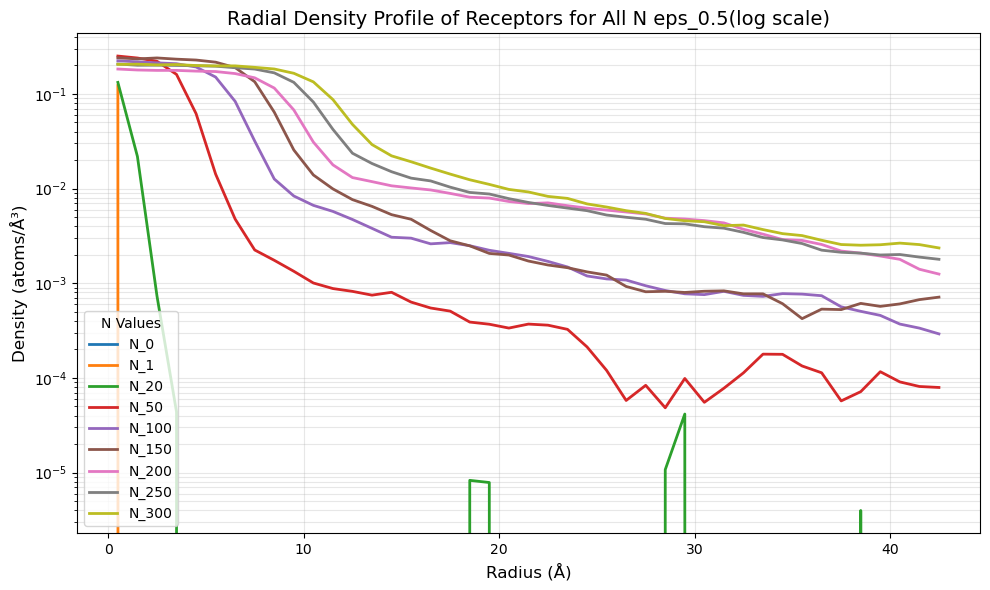


Combined receptor plot (log scale) saved at: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/all_N_receptor_radial_density_log_plot.png


In [116]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'

# Detect all folders starting with "N_"
n_folders = [f for f in os.listdir(root_folder) 
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
# Sort numerically by the number after N_
n_folders.sort(key=lambda x: int(x.split('_')[1]))

# Output plot path
output_plot = os.path.join(root_folder, 'all_N_receptor_radial_density_log_plot.png')

# Initialize plot
plt.figure(figsize=(10,6))

# Loop through folders
for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'receptor_radial_density_table.csv')
    
    if not os.path.isfile(csv_file):
        print(f"CSV not found in {folder_path}, skipping...")
        continue
    
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")
        continue
    
    # Check required columns
    required_cols = ['Radius (Å)', 'Cluster Density (atoms/Å³)']
    if not all(col in df.columns for col in required_cols):
        print(f"Required columns missing in {csv_file}, skipping...")
        continue
    
    # Extract data
    radius = df['Radius (Å)']
    cluster_density = df['Cluster Density (atoms/Å³)']

    plt.plot(radius, cluster_density, label=n, linewidth=2)

plt.xlabel('$r$ ($\sigma$)', fontsize=12)
plt.ylabel('Density (atoms/Å³)', fontsize=12)
plt.yscale('log')  # Log scale for y-axis
plt.title('Radial Density Profile of Receptors for All N eps_0.5(log scale)', fontsize=14)
plt.legend(title='N Values')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()

plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCombined receptor plot (log scale) saved at: {output_plot}")


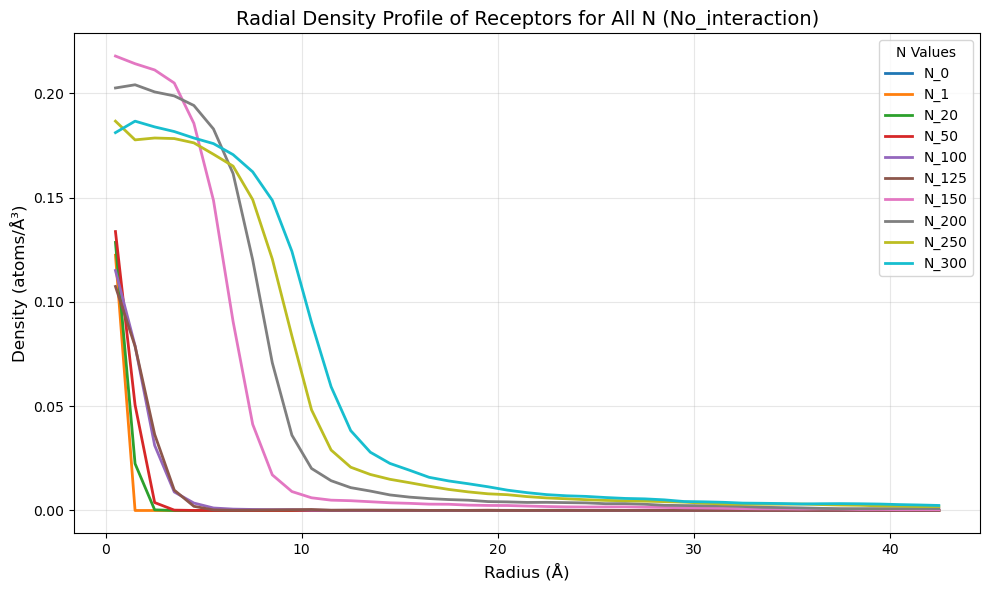


 Combined receptor plot saved at: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/all_N_receptor_radial_density_plot.png


In [103]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction'

# Detect all folders starting with "N_"
n_folders = [f for f in os.listdir(root_folder) 
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
# Sort numerically by the number after N_
n_folders.sort(key=lambda x: int(x.split('_')[1]))

# Output plot path
output_plot = os.path.join(root_folder, 'all_N_receptor_radial_density_plot.png')

# Initialize plot
plt.figure(figsize=(10,6))

# Loop through folders
for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'receptor_radial_density_table.csv')
    
    if not os.path.isfile(csv_file):
        print(f" CSV not found in {folder_path}, skipping...")
        continue
    
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f" Error reading {csv_file}: {e}")
        continue
    
    # Check required columns
    required_cols = ['Radius (Å)', 'Cluster Density (atoms/Å³)']
    if not all(col in df.columns for col in required_cols):
        print(f" Required columns missing in {csv_file}, skipping...")
        continue
    
    # Extract data
    radius = df['Radius (Å)']
    cluster_density = df['Cluster Density (atoms/Å³)']
    
    # Plot cluster density
    plt.plot(radius, cluster_density, label=n, linewidth=2)

# Plot formatting
plt.xlabel('$r$ ($\sigma$)', fontsize=12)
plt.ylabel('Density (atoms/Å³)', fontsize=12)
plt.title('Radial Density Profile of Receptors for All N (No_interaction)', fontsize=14)
plt.legend(title='N Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show plot
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Combined receptor plot saved at: {output_plot}")


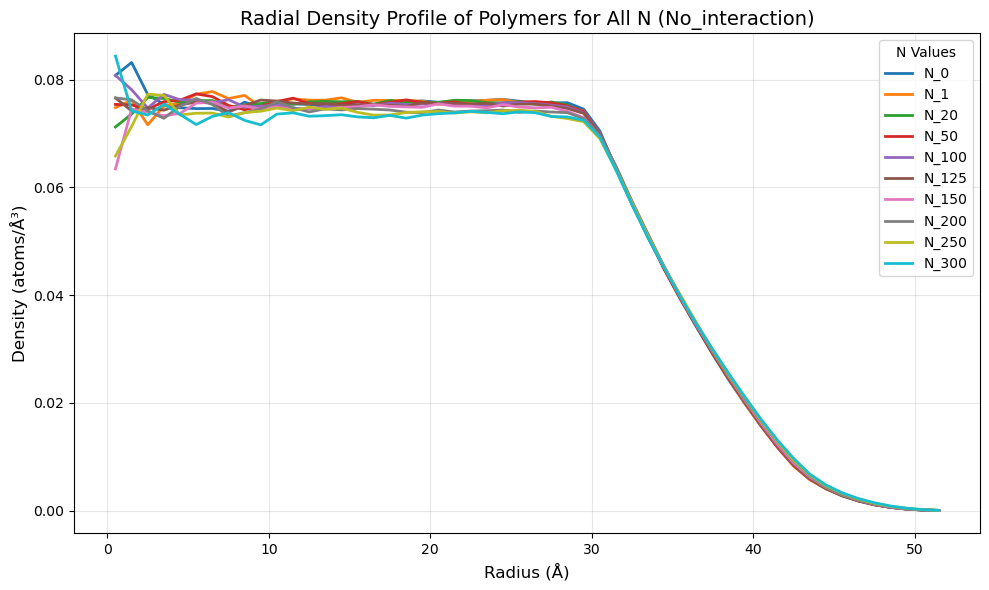


 Combined polymer plot saved at: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/all_N_polymer_radial_density_plot.png


In [104]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction'

# Detect all folders starting with "N_"
n_folders = [f for f in os.listdir(root_folder) 
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
# Sort numerically by the number after N_
n_folders.sort(key=lambda x: int(x.split('_')[1]))

# Output plot path
output_plot = os.path.join(root_folder, 'all_N_polymer_radial_density_plot.png')

# Initialize plot
plt.figure(figsize=(10,6))

# Loop through folders
for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'polymer_radial_density_table_sphere.csv')
    
    if not os.path.isfile(csv_file):
        print(f"CSV not found in {folder_path}, skipping...")
        continue
    
    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")
        continue
    
    # Check required columns
    required_cols = ['Radius(Å)', 'ClusterDensity(atoms/Å³)']
    if not all(col in df.columns for col in required_cols):
        print(f"Required columns missing in {csv_file}, skipping...")
        continue
    
    # Extract data
    radius = df['Radius(Å)']
    cluster_density = df['ClusterDensity(atoms/Å³)']
    
    # Plot cluster density
    plt.plot(radius, cluster_density, label=n, linewidth=2)

# Plot formatting
plt.xlabel('$r$ ($\sigma$)', fontsize=12)
plt.ylabel('Density (atoms/Å³)', fontsize=12)
plt.title('Radial Density Profile of Polymers for All N (No_interaction)', fontsize=14)
plt.legend(title='N Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show plot
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Combined polymer plot saved at: {output_plot}")


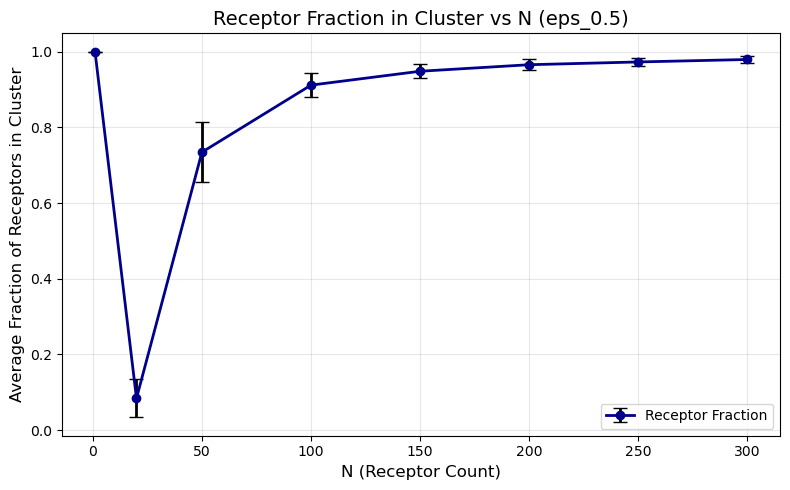


 Receptor fraction vs N (with error bars) saved to:
/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/receptor_fraction_vs_N_errorbars.png


In [105]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'

# Get all subfolders like N_1, N_20, N_50 ...
n_folders = [f for f in os.listdir(root_folder)
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort by numeric N value

n_values = []
avg_fractions = []
std_fractions = []  # standard deviation for error bars

for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'receptor_radial_density.csv')

    if not os.path.isfile(csv_file):
        print(f"Missing file: {csv_file}")
        continue

    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")
        continue

    if 'Fraction' not in df.columns:
        print(f"No 'Fraction' column found in {csv_file}")
        continue

    # Compute mean and std of receptor fraction
    avg_fraction = df['Fraction'].mean()
    std_fraction = df['Fraction'].std()
    n_value = int(n.split('_')[1])

    n_values.append(n_value)
    avg_fractions.append(avg_fraction)
    std_fractions.append(std_fraction)

# --- Plot Fraction vs N with error bars ---
plt.figure(figsize=(8,5))
plt.errorbar(n_values, avg_fractions, yerr=std_fractions, fmt='o-', color='darkblue',
             ecolor='black', capsize=5, linewidth=2, label='Receptor Fraction')

plt.xlabel('N (Receptor Count)', fontsize=12)
plt.ylabel('Average Fraction of Receptors in Cluster', fontsize=12)
plt.title('Receptor Fraction in Cluster vs N (eps_0.5)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
output_plot = os.path.join(root_folder, 'receptor_fraction_vs_N_errorbars.png')
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Receptor fraction vs N (with error bars) saved to:\n{output_plot}")

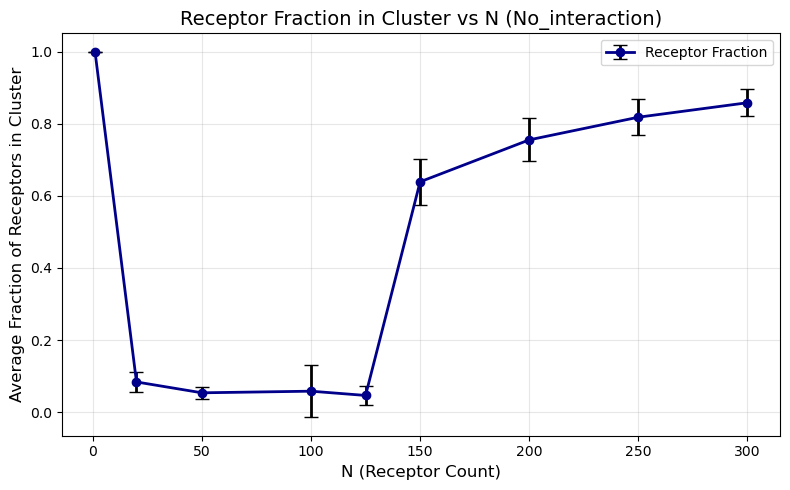


 Receptor fraction vs N (with error bars) saved to:
/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/receptor_fraction_vs_N_errorbars.png


In [106]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction'

# Get all subfolders like N_1, N_20, N_50 ...
n_folders = [f for f in os.listdir(root_folder)
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort by numeric N value

n_values = []
avg_fractions = []
std_fractions = []  # standard deviation for error bars

for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'receptor_radial_density.csv')

    if not os.path.isfile(csv_file):
        print(f"Missing file: {csv_file}")
        continue

    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")
        continue

    if 'Fraction' not in df.columns:
        print(f"No 'Fraction' column found in {csv_file}")
        continue

    # Compute mean and std of receptor fraction
    avg_fraction = df['Fraction'].mean()
    std_fraction = df['Fraction'].std()
    n_value = int(n.split('_')[1])

    n_values.append(n_value)
    avg_fractions.append(avg_fraction)
    std_fractions.append(std_fraction)

# --- Plot Fraction vs N with error bars ---
plt.figure(figsize=(8,5))
plt.errorbar(n_values, avg_fractions, yerr=std_fractions, fmt='o-', color='darkblue',
             ecolor='black', capsize=5, linewidth=2, label='Receptor Fraction')

plt.xlabel('N (Receptor Count)', fontsize=12)
plt.ylabel('Average Fraction of Receptors in Cluster', fontsize=12)
plt.title('Receptor Fraction in Cluster vs N (No_interaction)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
output_plot = os.path.join(root_folder, 'receptor_fraction_vs_N_errorbars.png')
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Receptor fraction vs N (with error bars) saved to:\n{output_plot}")

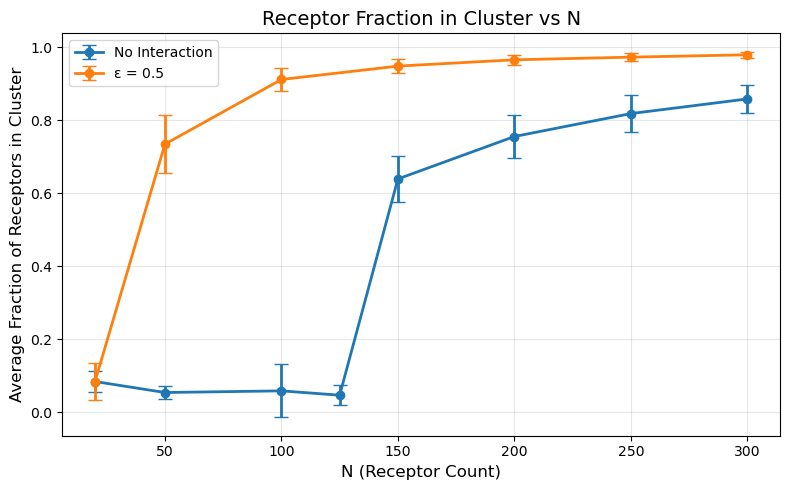


 Combined receptor fraction vs N plot saved to:
/home/user/Desktop/Anagha/Shin_Colab/Linker_2/receptor_fraction_vs_N_combined.png


In [107]:
root_folders = {
    'No Interaction': '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction',
    'ε = 0.5': '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'
}

plt.figure(figsize=(8, 5))

# --- Loop over each root and plot ---
for label, root_folder in root_folders.items():
    # Get all subfolders like N_1, N_20, N_50 ...
    n_folders = [
        f for f in os.listdir(root_folder)
        if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)
    ]
    n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort numerically by N

    n_values = []
    avg_fractions = []
    std_fractions = []    # standard deviation for error bars

    for n in n_folders:
        if n == "N_1":  
            continue
        folder_path = os.path.join(root_folder, n)
        csv_file = os.path.join(folder_path, 'receptor_radial_density.csv')

        if not os.path.isfile(csv_file):
            print(f"Missing file: {csv_file}")
            continue

        try:
            df = pd.read_csv(csv_file)
        except Exception as e:
            print(f"Error reading {csv_file}: {e}")
            continue

        if 'Fraction' not in df.columns:
            print(f"No 'Fraction' column found in {csv_file}")
            continue

        # Mean and standard deviation
        avg_fraction = df['Fraction'].mean()
        std_fraction = df['Fraction'].std()
        n_value = int(n.split('_')[1])

        n_values.append(n_value)
        avg_fractions.append(avg_fraction)
        std_fractions.append(std_fraction)

    # Plot with error bars
    plt.errorbar(
        n_values, avg_fractions, yerr=std_fractions,
        fmt='o-', capsize=5, linewidth=2, label=label
    )

plt.xlabel('N (Receptor Count)', fontsize=12)
plt.ylabel('Average Fraction of Receptors in Cluster', fontsize=12)
plt.title('Receptor Fraction in Cluster vs N', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

output_plot = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/receptor_fraction_vs_N_combined.png'
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Combined receptor fraction vs N plot saved to:\n{output_plot}")

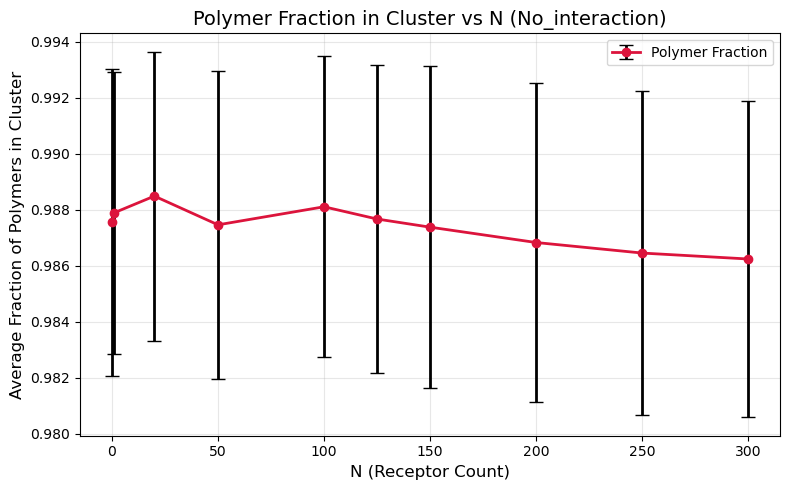


 Polymer fraction vs N (with error bars) saved to:
/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/fraction_vs_N_polymer_errorbars.png


In [111]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction'

# Identify subfolders named N_*
n_folders = [f for f in os.listdir(root_folder)
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort numerically by N value

n_values = []
avg_fractions = []
std_fractions = []  # standard deviation for error bars

for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'polymer_cluster_analysis_sphere.csv')
    if not os.path.isfile(csv_file):
        print(f"Missing file: {csv_file}")
        continue

    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")
        continue

    if 'Fraction' not in df.columns:
        print(f"No 'Fraction' column found in {csv_file}")
        continue

    # Compute mean and standard deviation of fraction for this N
    avg_fraction = df['Fraction'].mean()
    std_fraction = df['Fraction'].std()
    n_value = int(n.split('_')[1])

    n_values.append(n_value)
    avg_fractions.append(avg_fraction)
    std_fractions.append(std_fraction)

# --- Plot Fraction vs N with error bars ---
plt.figure(figsize=(8, 5))
plt.errorbar(n_values, avg_fractions, yerr=std_fractions, fmt='o-', color='crimson',
             ecolor='black', capsize=5, linewidth=2, label='Polymer Fraction')

plt.xlabel('N (Receptor Count)', fontsize=12)
plt.ylabel('Average Fraction of Polymers in Cluster', fontsize=12)
plt.title('Polymer Fraction in Cluster vs N (No_interaction)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
output_plot = os.path.join(root_folder, 'fraction_vs_N_polymer_errorbars.png')
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Polymer fraction vs N (with error bars) saved to:\n{output_plot}")

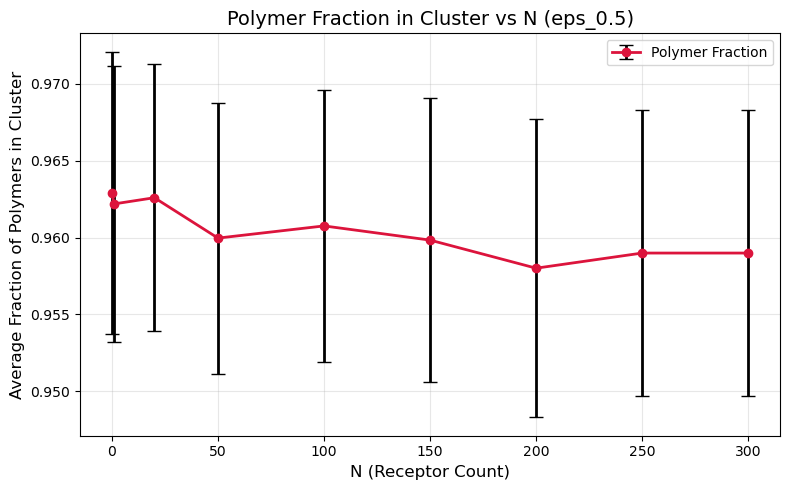


 Polymer fraction vs N (with error bars) saved to:
/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/fraction_vs_N_polymer_errorbars.png


In [98]:
root_folder = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'

# Identify subfolders named N_*
n_folders = [f for f in os.listdir(root_folder)
             if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)]
n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort numerically by N value

n_values = []
avg_fractions = []
std_fractions = []  # standard deviation for error bars

for n in n_folders:
    folder_path = os.path.join(root_folder, n)
    csv_file = os.path.join(folder_path, 'polymer_cluster_analysis.csv')

    if not os.path.isfile(csv_file):
        print(f"Missing file: {csv_file}")
        continue

    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"Error reading {csv_file}: {e}")
        continue

    if 'Fraction' not in df.columns:
        print(f"No 'Fraction' column found in {csv_file}")
        continue

    # Compute mean and standard deviation of fraction for this N
    avg_fraction = df['Fraction'].mean()
    std_fraction = df['Fraction'].std()
    n_value = int(n.split('_')[1])

    n_values.append(n_value)
    avg_fractions.append(avg_fraction)
    std_fractions.append(std_fraction)

# --- Plot Fraction vs N with error bars ---
plt.figure(figsize=(8, 5))
plt.errorbar(n_values, avg_fractions, yerr=std_fractions, fmt='o-', color='crimson',
             ecolor='black', capsize=5, linewidth=2, label='Polymer Fraction')

plt.xlabel('N (Receptor Count)', fontsize=12)
plt.ylabel('Average Fraction of Polymers in Cluster', fontsize=12)
plt.title('Polymer Fraction in Cluster vs N (eps_0.5)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
output_plot = os.path.join(root_folder, 'fraction_vs_N_polymer_errorbars.png')
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Polymer fraction vs N (with error bars) saved to:\n{output_plot}")



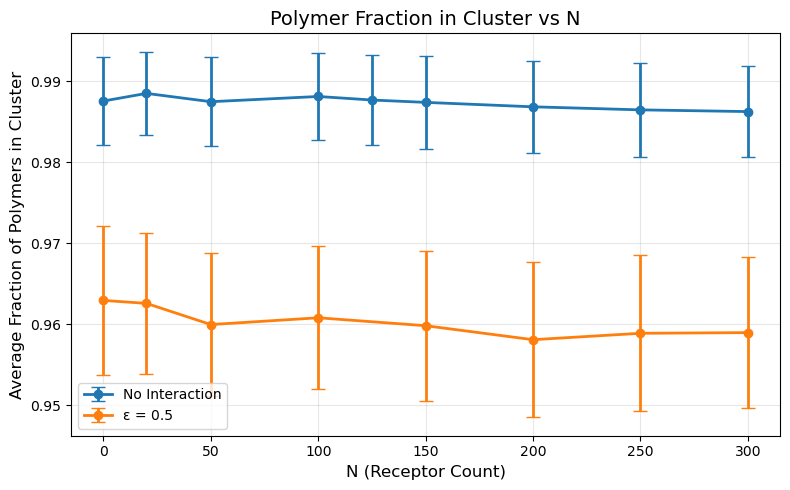


Combined polymer fraction vs N plot saved to:
/home/user/Desktop/Anagha/Shin_Colab/Linker_2/polymer_fraction_vs_N_combined.png


In [110]:
root_folders = {
    'No Interaction': '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction',
    'ε = 0.5': '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5'
}

plt.figure(figsize=(8, 5))

# --- Loop over each root and plot ---
for label, root_folder in root_folders.items():
    # Identify subfolders like N_1, N_20, etc.
    n_folders = [
        f for f in os.listdir(root_folder)
        if os.path.isdir(os.path.join(root_folder, f)) and re.match(r'^N_\d+$', f)
    ]
    n_folders.sort(key=lambda x: int(x.split('_')[1]))  # Sort numerically

    n_values = []
    avg_fractions = []
    std_fractions = []

    for n in n_folders:
        if n == "N_1":  # Skip N_1
            continue

        folder_path = os.path.join(root_folder, n)
        csv_file = os.path.join(folder_path, 'polymer_cluster_analysis_sphere.csv')

        if not os.path.isfile(csv_file):
            print(f"Missing file: {csv_file}")
            continue

        try:
            df = pd.read_csv(csv_file)
        except Exception as e:
            print(f"Error reading {csv_file}: {e}")
            continue

        if 'Fraction' not in df.columns:
            print(f"No 'Fraction' column found in {csv_file}")
            continue

        # Compute mean and std for this N
        avg_fraction = df['Fraction'].mean()
        std_fraction = df['Fraction'].std()
        n_value = int(n.split('_')[1])

        n_values.append(n_value)
        avg_fractions.append(avg_fraction)
        std_fractions.append(std_fraction)

    # Plot each dataset with error bars
    plt.errorbar(
        n_values, avg_fractions, yerr=std_fractions,
        fmt='o-', capsize=5, linewidth=2, label=label
    )

plt.xlabel('N (Receptor Count)', fontsize=12)
plt.ylabel('Average Fraction of Polymers in Cluster', fontsize=12)
plt.title('Polymer Fraction in Cluster vs N', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

output_plot = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/polymer_fraction_vs_N_combined.png'
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCombined polymer fraction vs N plot saved to:\n{output_plot}")


Saved rho CSV to: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/N_100/rho_radial_eps0p5_over_nointeraction.csv


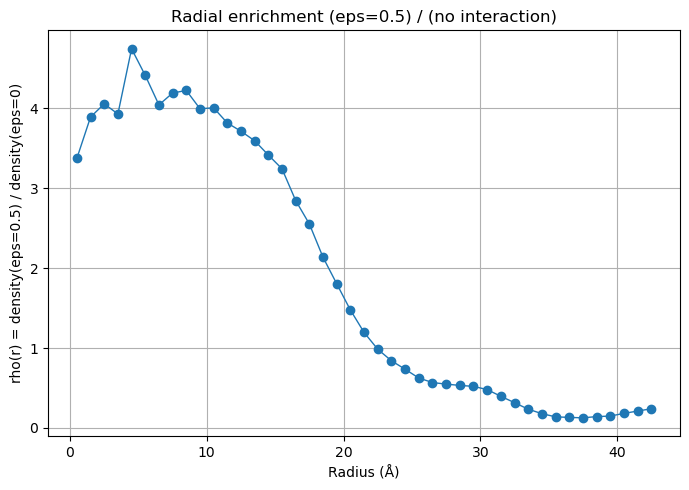

Saved plot to: /home/user/Desktop/Anagha/Shin_Colab/Linker_2/N_100/rho_vs_r_eps0p5_over_nointeraction.png
rho finite range: 0.12718323277223992 -> 4.745810055866004


In [1]:
# Compute rho(r) = density(eps=0.5) / density(eps=0) using your two CSVs
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ USER FILE PATHS (from your message) ------------------
csv_no_inter = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/No_interaction/N_100/polymer_radial_density_table_sphere.csv'
csv_eps05    = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/eps_0.5/N_100/polymer_radial_density_table_sphere.csv'

output_csv   = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/N_100/rho_radial_eps0p5_over_nointeraction.csv'
output_plot  = '/home/user/Desktop/Anagha/Shin_Colab/Linker_2/N_100/rho_vs_r_eps0p5_over_nointeraction.png'
# -------------------------------------------------------------------------

# small helper to pick plausible column names
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    # loose match
    lowcols = {c.lower().replace(" ", "").replace("(", "").replace(")", "").replace("å","a").replace("³","3"): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().replace(" ", "").replace("(", "").replace(")", "").replace("å","a").replace("³","3")
        for k, orig in lowcols.items():
            if key in k or k in key:
                return orig
    return None

# load files
if not os.path.exists(csv_no_inter):
    raise FileNotFoundError(csv_no_inter)
if not os.path.exists(csv_eps05):
    raise FileNotFoundError(csv_eps05)

df0 = pd.read_csv(csv_no_inter)
df5 = pd.read_csv(csv_eps05)

# detect radius column
radius_candidates = ["Radius(Å)", "Radius(Ang)", "Radius", "radius", "r"]
rcol = find_col(df5, radius_candidates)
if rcol is None:
    raise KeyError("Couldn't find a radius column in eps=0.5 CSV. Columns found: " + ", ".join(df5.columns))

# detect density or counts columns
# possible names produced by earlier cells: "ClusterDensity(atoms/Å³)","AllPolymerDensity(atoms/Å³)",
# or "AvgPolymersInShell", "AvgPolymerDensity(chains_per_A3)"
density_candidates = [
    "AllPolymerDensity(atoms/Å³)", "AllPolymerDensity(atoms/Å3)", "AllPolymerDensity",
    "ClusterDensity(atoms/Å³)", "ClusterDensity", "AvgPolymerDensity", "AvgPolymerDensity(chains_per_A3)",
    "AvgPolymerDensity(chains/Å³)", "Density", "Density(chains_per_A3)"
]
count_candidates = [
    "AvgPolymersInShell", "AvgPolymers", "AvgChains", "Count", "Counts", "N"
]

dens_col_5 = find_col(df5, density_candidates)
dens_col_0 = find_col(df0, density_candidates)
count_col_5 = find_col(df5, count_candidates)
count_col_0 = find_col(df0, count_candidates)

def compute_density_from_counts(df, rcol, count_col):
    # assume rcol is bin centers; infer bin edges by midpoints
    radii = df[rcol].values
    if len(radii) < 2:
        raise ValueError("Need >=2 radius bins to compute shell volumes.")
    diffs = np.diff(radii)
    bw = np.median(diffs)
    edges = np.concatenate(([radii[0] - bw/2.0], 0.5*(radii[:-1] + radii[1:]), [radii[-1] + bw/2.0]))
    r_in = edges[:-1]; r_out = edges[1:]
    shell_vol = (4.0/3.0) * np.pi * (r_out**3 - r_in**3)
    counts = df[count_col].values.astype(float)
    dens = counts / shell_vol
    return dens, shell_vol

# Obtain densities for both datasets (chains per Å^3)
if dens_col_5 is not None and dens_col_0 is not None:
    dens5 = df5[dens_col_5].values.astype(float)
    dens0 = df0[dens_col_0].values.astype(float)
    radii = df5[rcol].values
    # try align radii exactly, otherwise inner-join
    if len(dens5) != len(dens0) or not np.allclose(radii, df0[rcol].values, atol=1e-8):
        merged = pd.merge(df5[[rcol, dens_col_5]], df0[[rcol, dens_col_0]], on=rcol, how='inner', suffixes=('_5','_0'))
        if merged.empty:
            raise ValueError("Could not align radii between files; radii differ. Consider rebinning or checking CSVs.")
        radii = merged[rcol].values
        dens5 = merged[f"{dens_col_5}_5"].values.astype(float)
        dens0 = merged[f"{dens_col_0}_0"].values.astype(float)
else:
    # need counts present in both to compute densities
    if count_col_5 is None or count_col_0 is None:
        raise KeyError("Couldn't find density columns or compatible count columns in the CSVs.\n"
                       f"eps0.5 columns: {df5.columns.tolist()}\nno-interaction columns: {df0.columns.tolist()}")
    dens5, vol5 = compute_density_from_counts(df5, rcol, count_col_5)
    dens0, vol0 = compute_density_from_counts(df0, rcol, count_col_0)
    radii = df5[rcol].values

# compute rho = dens5 / dens0 (safe)
with np.errstate(divide='ignore', invalid='ignore'):
    rho = np.where(dens0 == 0, np.nan, dens5 / dens0)

# prepare and save output
outdf = pd.DataFrame({
    "Radius(Å)": radii,
    "Density_eps0p5(chains_per_A3)": dens5,
    "Density_no_interaction(chains_per_A3)": dens0,
    "rho_eps0p5_over_nointer": rho
})
os.makedirs(os.path.dirname(output_csv), exist_ok=True)
outdf.to_csv(output_csv, index=False)
print("Saved rho CSV to:", output_csv)

# plot (linear and log y as alternative)
plt.figure(figsize=(7,5))
plt.plot(radii, rho, marker='o', linestyle='-', linewidth=1)
plt.xlabel("Radius (Å)")
plt.ylabel("rho(r) = density(eps=0.5) / density(eps=0)")
plt.title("Radial enrichment (eps=0.5) / (no interaction)")
plt.grid(True)
plt.tight_layout()
os.makedirs(os.path.dirname(output_plot), exist_ok=True)
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()
print("Saved plot to:", output_plot)

# quick stats
finite = np.isfinite(rho)
if finite.any():
    print("rho finite range:", np.nanmin(rho[finite]), "->", np.nanmax(rho[finite]))
else:
    print("All rho values are NaN (likely dens0 == 0 everywhere).")
